# Tutorial on How to Use FIM-PP

This notebook shows the recommended Hugging Face workflow for the point-process model from {cite}`fim_pp`: load the pretrained model with `AutoModel.from_pretrained(...)`, download a small example dataset from the Hub, prepare the context/inference tensors, visualize the inferred intensities, and finish with a fine-tuning command template.


## Installation

Install the OpenFIM package first so the remote code can import the `fim` modules:

```bash
pip install -e .
```

The tutorial also uses `huggingface_hub` to download the example dataset.


In [1]:
from pathlib import Path
import warnings

import torch
from huggingface_hub import snapshot_download
from transformers import AutoModel

from point_process_tutorial_helper import load_hawkes_tensors, move_to_device, plot_intensity_comparison, prepare_hawkes_batch

warnings.filterwarnings("ignore")
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    if torch.backends.mps.is_available():
        print("MPS is not yet supported for this FIM-PP tutorial path; using CPU instead.")
    device = torch.device("cpu")
device


MPS is not yet supported for this FIM-PP tutorial path; using CPU instead.


device(type='cpu')

## Load the Pretrained Model

The standardized user-facing path is now the Transformers AutoModel interface.


In [2]:
model = AutoModel.from_pretrained("FIM4Science/FIM-PP", trust_remote_code=True)
model = model.to(device)
model.eval()


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

FIMHawkes(
  (mark_encoder): Linear(in_features=22, out_features=256, bias=True)
  (time_encoder): SineTimeEncoding(
    (linear_embedding): Linear(in_features=1, out_features=1, bias=True)
    (periodic_embedding): Sequential(
      (0): Linear(in_features=1, out_features=255, bias=True)
      (1): SinActivation()
    )
  )
  (delta_time_encoder): SineTimeEncoding(
    (linear_embedding): Linear(in_features=1, out_features=1, bias=True)
    (periodic_embedding): Sequential(
      (0): Linear(in_features=1, out_features=255, bias=True)
      (1): SinActivation()
    )
  )
  (evaluation_mark_encoder): Linear(in_features=22, out_features=256, bias=True)
  (context_summary_pooling): AttentionOperator(
    (res_layers): ModuleList(
      (0): ResidualAttentionLayer(
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=2048, bias=True)
        

## Download Example Data

The tutorial dataset is stored as raw tensors on Hugging Face. We download the snapshot and load the `.pt` files directly.


In [3]:
dataset_root = Path(snapshot_download(repo_id="FIM4Science/10D-Hawkes", repo_type="dataset"))
dataset_root


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

PosixPath('/Users/dberghaus/.cache/huggingface/hub/datasets--FIM4Science--10D-Hawkes/snapshots/63a12564d24e7ab41e0381b62528781a95036884')

In [4]:
tensors = load_hawkes_tensors(dataset_root)
sorted(tensors)


['event_times', 'event_types']

## Build a Context / Inference Batch

We hold out a single path for inference and use the remaining paths as context. The helper also builds a dense evaluation grid for plotting the intensity curves between events.


In [5]:
batch = prepare_hawkes_batch(tensors, sample_idx=0, inference_path_idx=0, num_points_between_events=10)
batch = move_to_device(batch, device)

for key, value in batch.items():
    if torch.is_tensor(value):
        print(f"{key}: {tuple(value.shape)}")
    else:
        print(f"{key}: {value}")


context_event_times: (1, 1999, 100, 1)
context_event_types: (1, 1999, 100, 1)
context_seq_lengths: (1, 1999)
inference_event_times: (1, 1, 100, 1)
inference_event_types: (1, 1, 100, 1)
inference_seq_lengths: (1, 1)
intensity_evaluation_times: (1, 1, 1100)
num_marks: 10


## Run Zero-Shot Inference


In [6]:
with torch.no_grad():
    output = model(batch)

sorted(output.keys())


['intensity_function', 'losses', 'predicted_intensity_values']

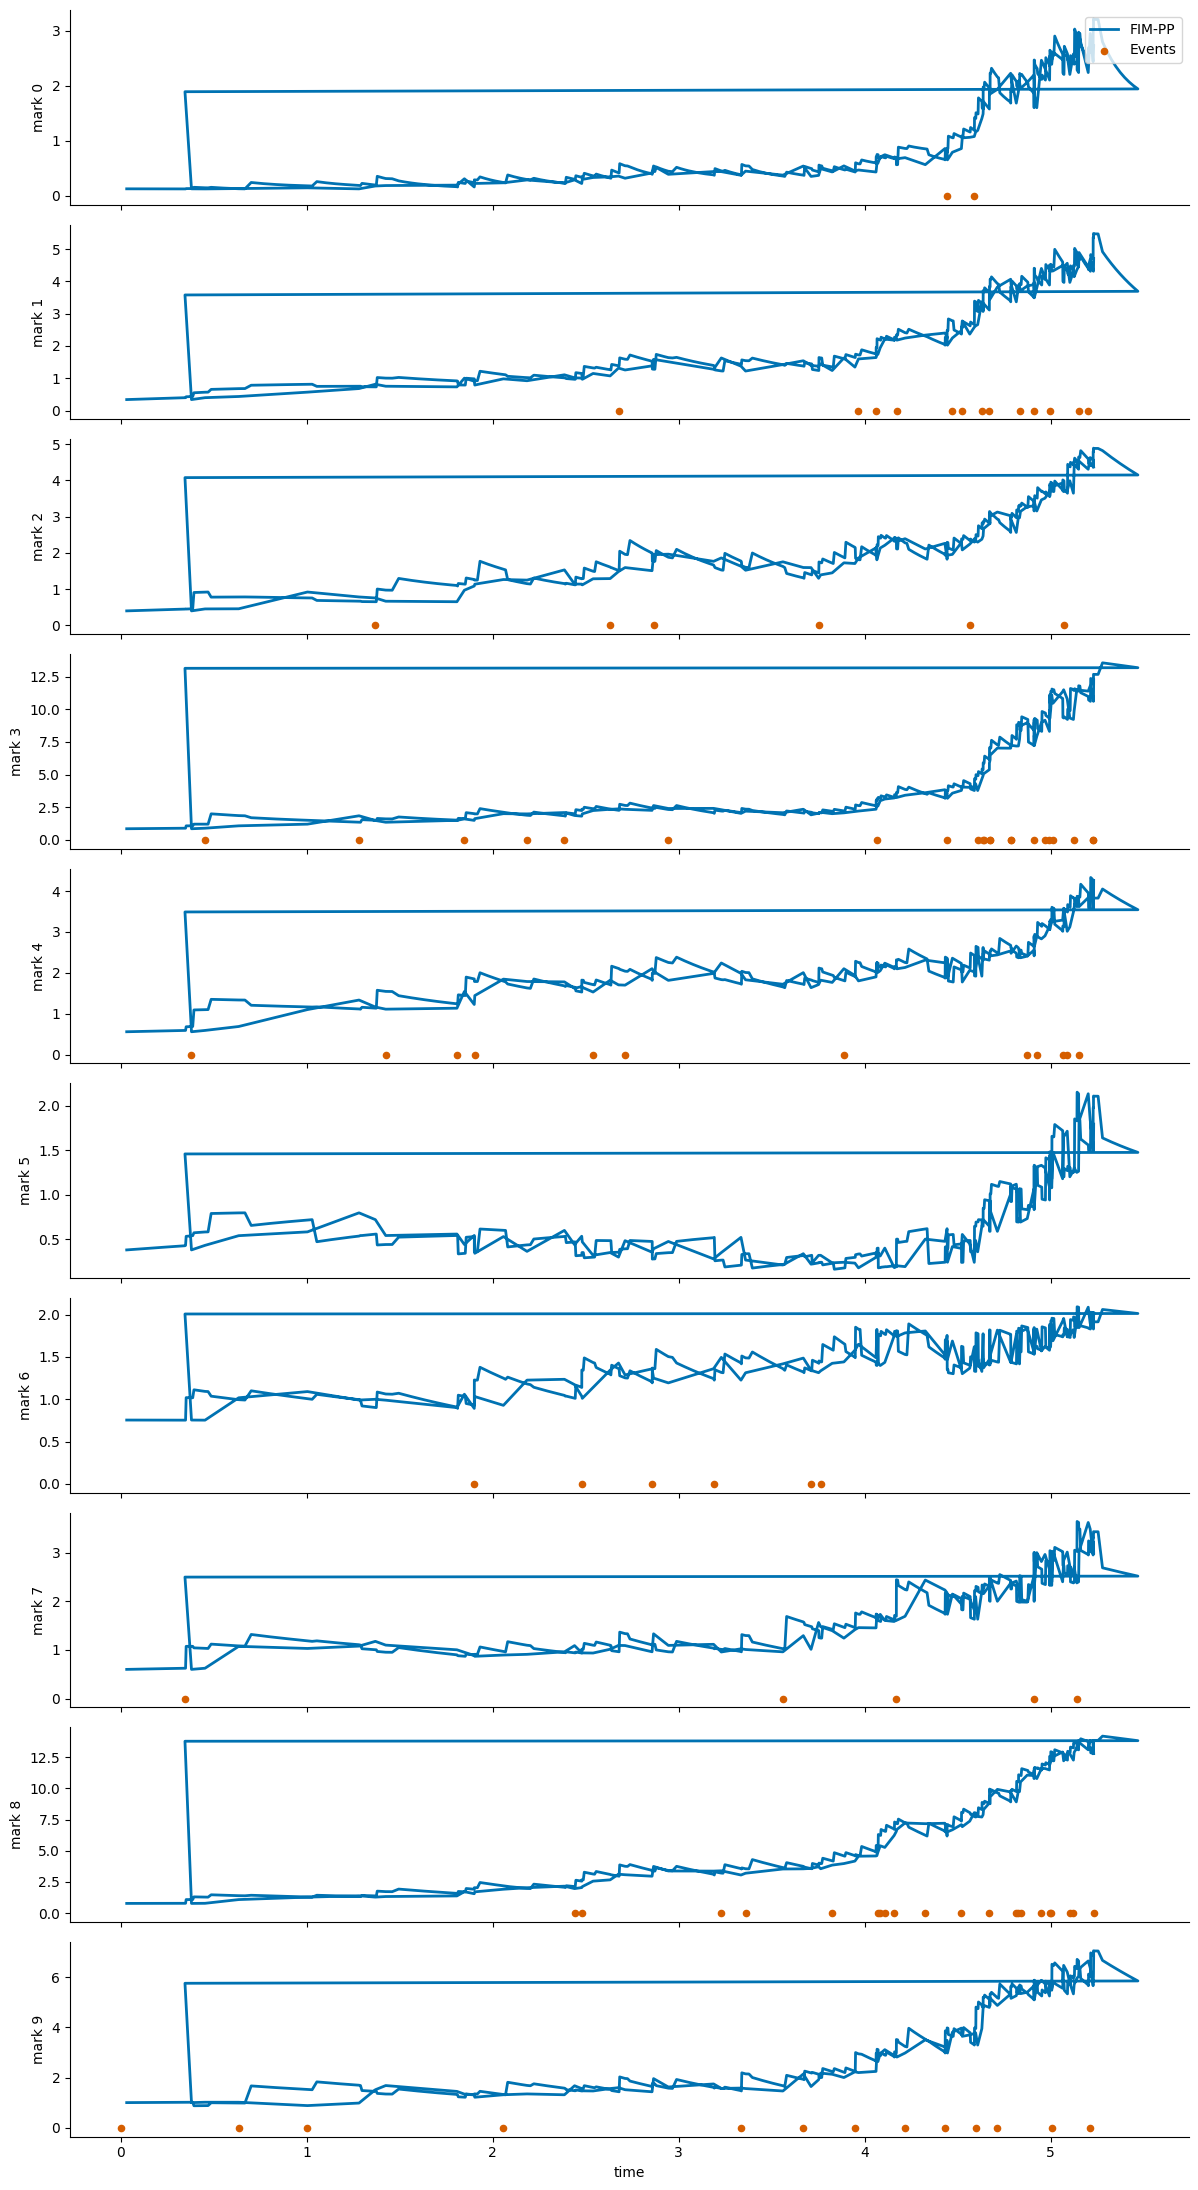

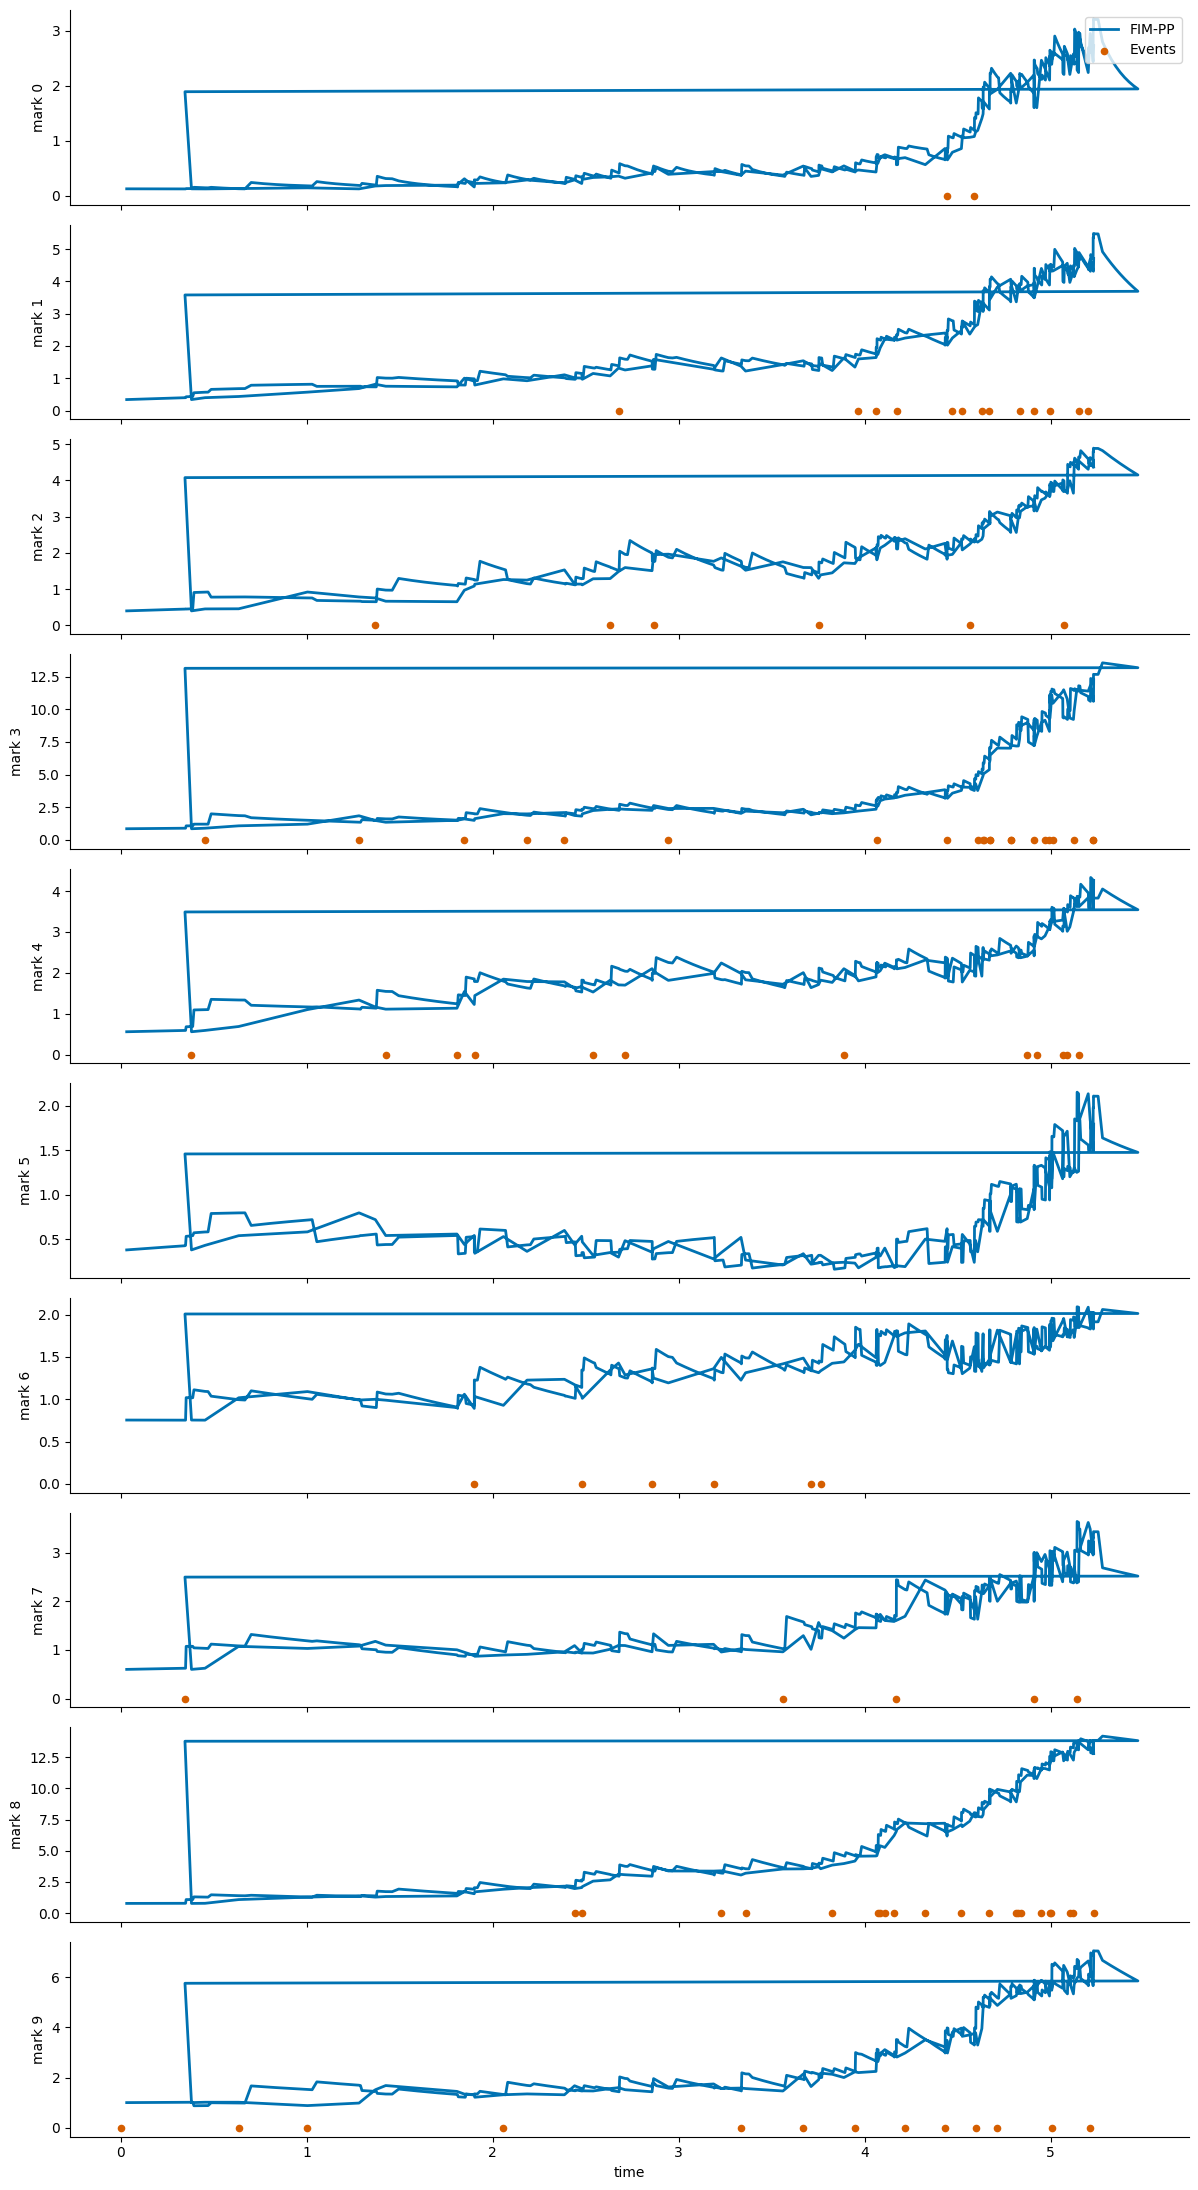

In [7]:
fig = plot_intensity_comparison(output, batch, path_idx=0)
fig


## Fine-Tuning Starting from FIM-PP

A short fine-tuning run can be started with the existing Hawkes entrypoint. The point-process checkpoint is the initialization source, while the dataset can be either a local tensor folder or an EasyTPP dataset id.

```bash
python scripts/hawkes/fim_finetune.py \
  --config configs/train/hawkes/david.yaml \
  --dataset easytpp/retweet \
  --resume_model /path/to/FIM-PP/model-checkpoint.pth \
  --epochs 200 \
  --val-every 10
```

For local debugging, the lower-level fallback `fim.models.hawkes.FIMHawkes.load_model(...)` is still available, but the primary public workflow should use `AutoModel.from_pretrained(...)`.
